<a href="https://colab.research.google.com/github/Yashhh7g/ML-PROJECT/blob/main/spamdetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

import nltk
import string

In [7]:
import pandas as pd

# If 'spam.csv' is not found, you'll need to upload it to your Colab environment.
# You can do this by clicking the 'Files' icon on the left sidebar,
# then clicking the 'Upload to session storage' icon (folder with an arrow pointing up),
# and selecting your 'spam.csv' file.
# Alternatively, if you have it in Google Drive, you can mount your Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# Then adjust the path accordingly, e.g., 'df = pd.read_csv('/content/drive/MyDrive/spam.csv', encoding='latin-1')'

# Assuming 'spam.csv' is uploaded to the root directory of the Colab environment:
df = pd.read_csv("spam.csv", encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
import os

# List files in the current directory
print(os.listdir())

['.config', 'spam.csv', 'sample_data']


In [9]:
df = df[['v1', 'v2']]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

In [11]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [12]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

def transform_text(text):

    text = text.lower()

    words = text.split()

    clean_words = []

    for word in words:

        if word.isalnum():

            if word not in stopwords.words('english'):

                clean_words.append(ps.stem(word))

    return " ".join(clean_words)

In [13]:
df['transformed'] = df['message'].apply(transform_text)

df.head()

,label,message,transformed
0,0,"Go until jurong point, crazy.. Available only ...",go jurong avail bugi n great world la e cine g...
1,0,Ok lar... Joking wif u oni...,ok joke wif u
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,u dun say earli u c alreadi
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goe live around though


In [14]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transformed']).toarray()

y = df['label'].values

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [17]:
pred = model.predict(X_test)

In [18]:
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9659192825112107


In [19]:
sample = "Congratulations! You won a free iPhone"

sample = transform_text(sample)

vector = tfidf.transform([sample])

result = model.predict(vector)[0]

if result == 1:
    print("Spam")
else:
    print("Not Spam")

Not Spam


In [20]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))

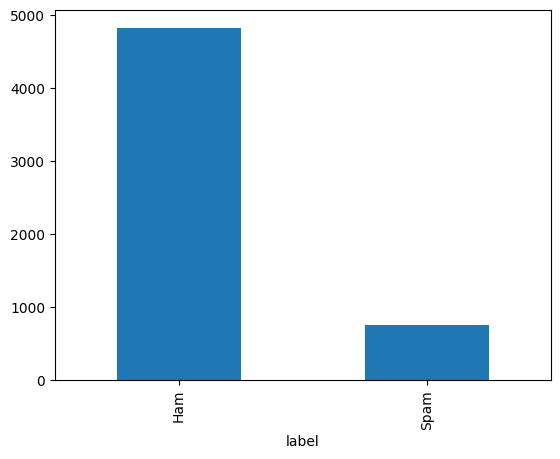

In [21]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.xticks([0,1], ['Ham','Spam'])

plt.show()

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[965   0]
 [ 38 112]]


Email Message
      ↓
Text Cleaning
      ↓
TF-IDF Vectorization
      ↓
Naive Bayes Model
      ↓
Spam / Not Spam